# Assignment 2: The Algorithmic Audit


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(2026)
print('Toolkit loaded successfully.')

Toolkit loaded successfully.


## Phase 1: The Robustness Audit (Topic 4)
### Step 1.1: The "Latency" Trap

In [9]:
import numpy as np

np.random.seed(2026)

normal_traffic = np.random.randint(20, 50, 980)
spike_traffic = np.random.randint(1000, 5000, 20)

latency_logs = np.concatenate([normal_traffic, spike_traffic])

print(latency_logs.mean())
print(np.median(latency_logs))

93.735
35.0


### Step 1.2: Manual MAD vs. Standard Deviation

In [ ]:
def calculate_mad(data):
    # 1. Calculate median
    median = np.median(data)
    
    # 2. Calculate absolute deviations
    deviations = np.abs(data - median)
    
    # 3. Return median of deviations
    mad = np.median(deviations)
    return mad

# Compare SD vs MAD
sd = np.std(latency_logs)
mad = calculate_mad(latency_logs)

print("Standard Deviation:", round(sd, 2))
print("MAD:", round(mad, 2))

The Standard Deviation is heavily affected by extreme values because it squares the distance from the mean, so the 20 spike requests between 1000ms–5000ms dramatically inflate it. The MAD remains stable because it uses the median and absolute deviations, making it resistant to outliers. Since 980 of the 1000 requests are normal values, the MAD better reflects the typical latency of the system


## Phase 2: The Probability Audit (Topic 5)
### Step 2.1: The False Positive Paradox

In [18]:
def bayesian_audit(prior, sensitivity, specificity):
    false_positive_rate = 1 - specificity
    
    p_flagged = (sensitivity * prior) + (false_positive_rate * (1 - prior))
    posterior = (sensitivity * prior) / p_flagged
    
    return posterior


sensitivity = 0.98
specificity = 0.98

scenarios = {
    "Bootcamp": 0.50,
    "Econ Class": 0.05,
    "Honors Seminar": 0.001
}

for scenario, prior in scenarios.items():
    posterior = bayesian_audit(prior, sensitivity, specificity)
    print(scenario, ":", round(posterior * 100, 2), "%")

Bootcamp : 98.0 %
Econ Class : 72.06 %
Honors Seminar : 4.68 %


The results show that the same plagiarism detector becomes much less useful as cheating becomes rarer. In the Bootcamp scenario, a flagged student is very likely to actually be cheating, but in the Honors Seminar, the posterior probability is only about 4.67%. This happens because false positives begin to dominate when the base rate is extremely low, even with 98% sensitivity and specificity.

## Phase 3: The Bias Audit (Topic 6)
### Step 3.1: Detecting Sample Ratio Mismatch (SRM)

In [20]:
import numpy as np

observed = np.array([50250, 49750])
expected = np.array([50000, 50000])

chi_square_stat = 0

for obs, exp in zip(observed, expected):
    chi_square_stat += (obs - exp) ** 2 / exp

critical_value = 3.84

print("Observed:", observed)
print("Expected:", expected)
print("Chi-Square Statistic:", round(chi_square_stat, 4))

if chi_square_stat > critical_value:
    print("Conclusion: The experiment is INVALID due to Sample Ratio Mismatch.")
else:
    print("Conclusion: The experiment does not show evidence of SRM.")

Observed: [50250 49750]
Expected: [50000 50000]
Chi-Square Statistic: 2.5
Conclusion: The experiment does not show evidence of SRM.


## Phase 4: AI Expansion — The Co-Pilot Era
### Task 4.1: The "Memecoin Graveyard" — Survivorship Bias Simulation

=== Survivorship Bias Audit: Memecoin Graveyard ===
Total tokens launched         : 10,000
Survivor threshold (Top 1%)   : $83,432
Number of survivors           : 100

Mean Market Cap — ALL tokens  : $7,961
Mean Market Cap — SURVIVORS   : $359,556
Bias multiplier               : 45.2x

VERDICT: Studying only the top 1% of tokens overstates the
"average" return by ~45x. This is Survivorship Bias in action.


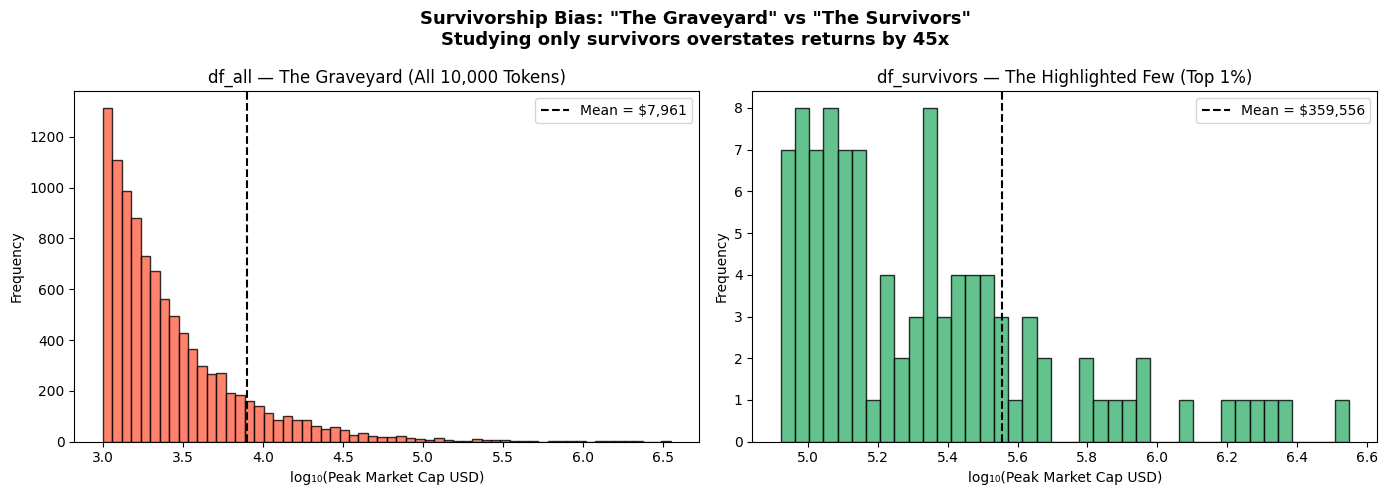

In [21]:
np.random.seed(42)
N_TOKENS = 10_000

# Pareto distribution: shape=1 (heavy tail), scale in $USD
# Most tokens peak near $1k; a handful reach millions
peak_market_caps = (np.random.pareto(a=1.0, size=N_TOKENS) + 1) * 1_000

df_all = pd.DataFrame({'peak_market_cap_usd': peak_market_caps,
                        'status': 'failed'})

# Survivors = top 1% by peak market cap
threshold = np.percentile(peak_market_caps, 99)
df_survivors = df_all[df_all['peak_market_cap_usd'] >= threshold].copy()
df_survivors['status'] = 'survived'

mean_all       = df_all['peak_market_cap_usd'].mean()
mean_survivors = df_survivors['peak_market_cap_usd'].mean()

print('=== Survivorship Bias Audit: Memecoin Graveyard ===')
print(f'Total tokens launched         : {N_TOKENS:,}')
print(f'Survivor threshold (Top 1%)   : ${threshold:,.0f}')
print(f'Number of survivors           : {len(df_survivors):,}')
print()
print(f'Mean Market Cap — ALL tokens  : ${mean_all:,.0f}')
print(f'Mean Market Cap — SURVIVORS   : ${mean_survivors:,.0f}')
print(f'Bias multiplier               : {mean_survivors/mean_all:.1f}x')
print()
print('VERDICT: Studying only the top 1% of tokens overstates the')
print(f'"average" return by ~{mean_survivors/mean_all:.0f}x. This is Survivorship Bias in action.')

# --- Dual histogram ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graveyard (log scale to handle the extreme range)
axes[0].hist(np.log10(df_all['peak_market_cap_usd'] + 1), bins=60,
             color='tomato', edgecolor='k', alpha=0.8)
axes[0].axvline(np.log10(mean_all), color='black', linestyle='--',
                label=f'Mean = ${mean_all:,.0f}')
axes[0].set_title('df_all — The Graveyard (All 10,000 Tokens)')
axes[0].set_xlabel('log₁₀(Peak Market Cap USD)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Survivors
axes[1].hist(np.log10(df_survivors['peak_market_cap_usd'] + 1), bins=40,
             color='mediumseagreen', edgecolor='k', alpha=0.8)
axes[1].axvline(np.log10(mean_survivors), color='black', linestyle='--',
                label=f'Mean = ${mean_survivors:,.0f}')
axes[1].set_title('df_survivors — The Highlighted Few (Top 1%)')
axes[1].set_xlabel('log₁₀(Peak Market Cap USD)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Survivorship Bias: "The Graveyard" vs "The Survivors"\n'
             'Studying only survivors overstates returns by {:.0f}x'.format(mean_survivors/mean_all),
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()